## Map-to-Prediciton 

This book takes in a calibrated water elevation map for a specific site and a set of test images and predicits the water in each image in (ft). 

In [166]:
import os
import glob
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm
from PIL import Image
import cv2
import torch
import json


## Existing Sites

Runs with an existing `run_config.json`:

In [2]:
site_list = sorted(glob.glob('cameras/*/*/run_config.json'))
for i, cfg in enumerate(site_list):
    parts = cfg.split(os.sep)
    print(f"Site {i} = '{parts[1]}'")
    print()

Site 0 = 'CA_Arroyo_DE_LA_Laguna_A_Corte_Madrid_nr_Pleasanton'

Site 1 = 'OK_Illinois_River_near_Moodys'

Site 2 = 'SC_Waccamaw_River_at_SC_22_below_Longs'

Site 3 = 'VA_DIFFICULT_RUN_ABOVE_FOX_LAKE_NEAR_FAIRFAX'

Site 4 = 'WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet'

Site 5 = 'WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet'



## Configuration

In [134]:
# Select site and test dierctory. The test data will be drawn from the specified folder for the camera

##### Input ####
site_selection = 4
test_run_name = 'test_2025-03-25'

################

cfg_path = site_list[site_selection]

if os.path.exists(cfg_path):
    with open(cfg_path) as f:
        cfg = json.load(f)

camera_id = cfg.get('camera_id')
run_name  = cfg.get('run_name')
run_dir = f'cameras/{camera_id}/{run_name}'

evel_path = f'{run_dir}/depth/calibrated_elevation.npy'
depth_path = f'{run_dir}/depth/relative_depth.npy'

print(f'Using elevation map from: {evel_path}')

test_dir = f'cameras/{camera_id}/{test_run_name}'

images_dir = f'{test_dir}/images'
masks_dir = f'{test_dir}/masks'
csv_path = f'{test_dir}/images_and_data.csv'

# Output directory
output_dir = f'{test_dir}/predicitons'
os.makedirs(output_dir, exist_ok=True)

print(f"Loading data from: {csv_path}")
print(f"Output will be saved to: {output_dir}")

Using elevation map from: cameras/WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet/event_2025-06-23/depth/calibrated_elevation.npy
Loading data from: cameras/WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet/test_2025-03-25/images_and_data.csv
Output will be saved to: cameras/WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet/test_2025-03-25/predicitons


## Load Elevation Map and Data


No quality_flag column found - using all masks
(Run notebook 02.5 to review and flag bad masks)
Loaded 114 records

Columns: ['Unnamed: 0', 'image_times', 'image_names', 'data_times', 'site_no', '00060', '00060_cd', '00065', '00065_cd', '63160', '63160_cd', 'time_diff_sec', 'mask_filename']

First few rows:


,image_names,mask_filename
0,WI_East_Branch_Pecatonica_River_near_Blanchard...,00000_obj1.npy
1,WI_East_Branch_Pecatonica_River_near_Blanchard...,00001_obj1.npy
2,WI_East_Branch_Pecatonica_River_near_Blanchard...,00002_obj1.npy
3,WI_East_Branch_Pecatonica_River_near_Blanchard...,00003_obj1.npy
4,WI_East_Branch_Pecatonica_River_near_Blanchard...,00004_obj1.npy


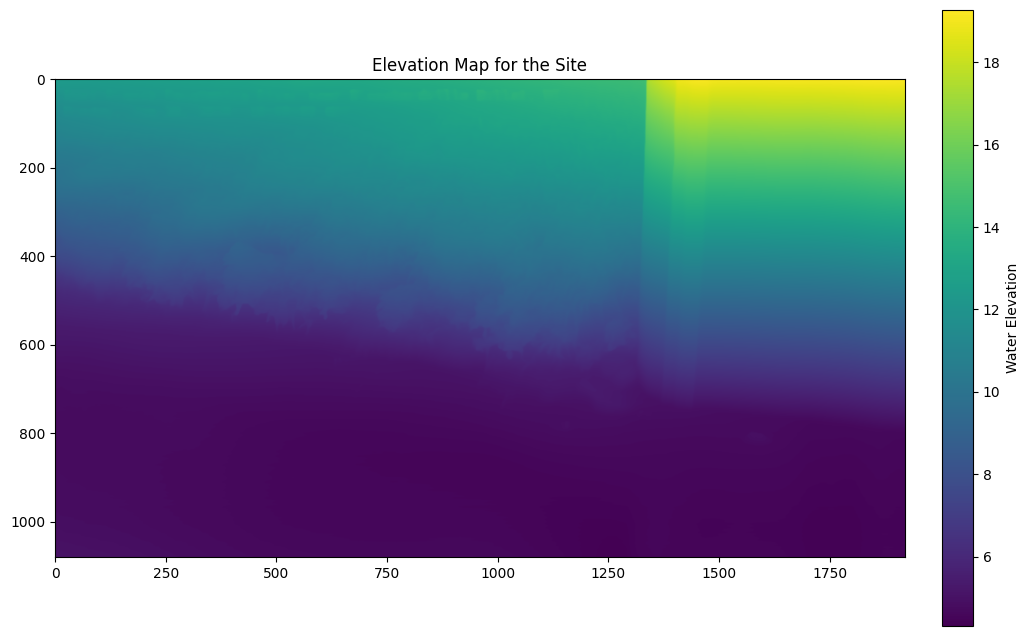

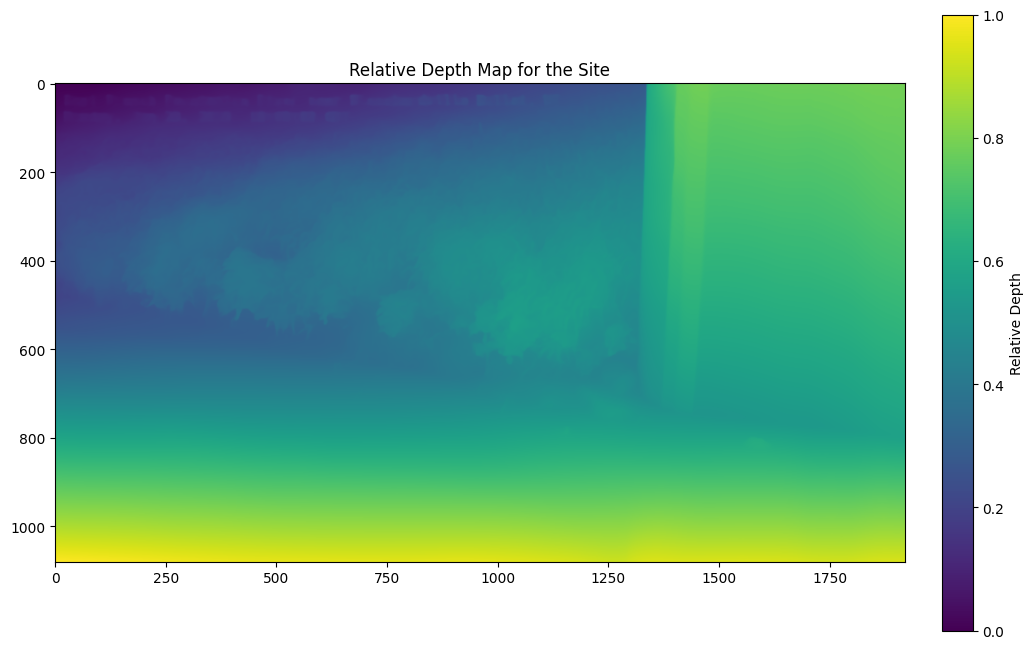

In [148]:
elevation_map = np.load(evel_path)
rel_depth_map = np.load(depth_path)
# Rescale relative depth map to be from 0-1 with 1 being closest 
rel_depth_map = (rel_depth_map - np.min(rel_depth_map))/(np.max(rel_depth_map)-np.min(rel_depth_map))

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(elevation_map)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Water Elevation')
plt.title("Elevation Map for the Site")

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(rel_depth_map)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Relative Depth')
plt.title("Relative Depth Map for the Site")

# Load the CSV with images, masks, and gage height data
df = pd.read_csv(csv_path)

# Filter out bad quality masks if quality_flag column exists
if 'quality_flag' in df.columns:
    n_bad = (df['quality_flag'] == 'bad').sum()
    if n_bad > 0:
        print(f"\nFound {n_bad} masks marked as 'bad' - excluding from analysis")
        bad_indices = df[df['quality_flag'] == 'bad'].index.tolist()
        print(f"Excluded indices: {bad_indices}")
        df = df[df['quality_flag'] != 'bad'].reset_index(drop=True)
        print(f"Remaining records after filtering: {len(df)}")
    else:
        print(f"\nAll masks marked as 'good' - no filtering applied")
else:
    print(f"\nNo quality_flag column found - using all masks")
    print(f"(Run notebook 02.5 to review and flag bad masks)")


print(f"Loaded {len(df)} records")

print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
display(df[['image_names', 'mask_filename']].head())


In [5]:
def load_mask(mask_path):
    """
    Load a mask from a .npy file.
    
    Args:
        mask_path: Path to .npy mask file
    
    Returns:
        Binary mask array
    """
    mask = np.load(mask_path)
    if mask.ndim == 3:
        mask = mask.squeeze()
    return mask.astype(bool)



In [215]:
import weightedstats as ws 

def predict_elevation(elevation_map, rel_depth_map, water_mask, prediction_method="weighted_median", return_verbose = False):
    """
    Predicts the water eleveation from an image and elevation map using median 
    
    Args:
        elevation_map: Map of water elevations for the site
        water_mask: Mask of the water 
        prediction_method: Method used to predict the water level [weighted_median, median, mean, mode]
    Returns:
        predicted_elevation: Predicted water elevation
    """
    # Find edge by subtracting the erroded image
    kernel = np.ones((3,3), np.uint8)
    erosion = cv2.erode(water_mask.astype(np.uint8), kernel, iterations=1)
    edges = cv2.subtract(water_mask.astype(np.uint8), erosion)
    # Dialate to increase the edge size 
    edges = cv2.dilate(edges.astype(np.uint8), kernel, iterations=1)

    # Calculate the the sizes of all edge peices and remove if much shorter than longest edge 
    _, labels, stats, _ = cv2.connectedComponentsWithStats(edges, connectivity=4)
    areas = stats[:, cv2.CC_STAT_AREA]

    # Find all edges that have an area of at least 25% of the largest non backgorund area 
    valid_labels = np.argwhere(areas> areas[1]*.25)
    # Remove backgound label 
    valid_labels = valid_labels[valid_labels != 0]

    # Update edges to only use valid edges
    edges = np.isin(labels, valid_labels)


    # Get elevation pixels for the water edge
    elevation_vals = elevation_map[edges]
    # Get depth info to weight pixels closer to the camera
    depth_info = rel_depth_map[edges]
    

    if prediction_method == "weighted_median":
        predicted_elevation = ws.weighted_median(elevation_vals, weights= depth_info)

    elif prediction_method == "median":
        predicted_elevation = np.median(elevation_vals)

    elif prediction_method == "mean":
        predicted_elevation = np.mean(elevation_vals)

    elif prediction_method == "mode":
        counts, bin_edges = np.histogram(elevation_vals)
        mode_pred_idx = np.argmax(counts)
        predicted_elevation = np.mean((bin_edges[mode_pred_idx],bin_edges[mode_pred_idx+1]))
    
    else: 
        raise ValueError("Invalid prediction method specified")

    if return_verbose == True:
        return predicted_elevation, elevation_vals, edges


    return predicted_elevation

def get_specific_est_info(index, elevation_map, rel_depth_map, images_df, images_dir, masks_dir):
    image_info = images_df.iloc[index]

    # Ground values 
    true_water_elevations = images_df['00065']
    true_val = true_water_elevations[index]   

    # Load Image
    image_path = os.path.join(images_dir, image_info['image_names'])
    water_image = cv2.cvtColor(cv2.imread(image_path), code=cv2.COLOR_BGR2RGB)

    # Load Mask
    mask_path = os.path.join(masks_dir, image_info['mask_filename'])
    water_mask = load_mask(mask_path)

    # Predict Water Level
    predicted, pred_vals, edges = predict_elevation(elevation_map, rel_depth_map, water_mask, return_verbose=True)
    min_predicted = np.min(pred_vals)
    max_predicted = np.max(pred_vals)

    mean_pred = np.mean(pred_vals)

    counts, bin_edges = np.histogram(pred_vals, )
    mode_pred_idx = np.argmax(counts)
    mode_pred = np.mean((bin_edges[mode_pred_idx],bin_edges[mode_pred_idx+1]))

    # Plot Edge Used for Prediction
    plt.figure()
    plt.imshow(edges*elevation_map, vmin=min_predicted, vmax=max_predicted)
    plt.title(f"Predicted: {predicted:.2f}, True: {true_val:.2f}")
    plt.colorbar()

    # Plot depth information along the edge
    plt.figure()
    plt.imshow(rel_depth_map*edges)
    plt.title(f"Relative Depth Info")
    plt.colorbar()

    # Plot Histogram for Values used in Prediction 
    plt.figure()
    plt.hist(pred_vals)
    plt.axvline(x=predicted, color='red', linestyle='dashed', linewidth=2, label='Predicted')
    plt.axvline(x=mean_pred, color='green', linestyle='dashed', linewidth=2, label='Mean')
    plt.axvline(x=mode_pred, color='yellow', linestyle='dashed', linewidth=2, label='Mode')
    plt.title(f"Predicted: {predicted:.2f}, True: {true_val:.2f}")
    plt.legend(["Predicted", "Mean", "Mode"])

    # Show image with water mask
    plt.figure()
    plt.imshow(water_image)
    plt.imshow(water_mask, alpha=0.1)

    # Show image without water mask
    plt.figure()
    plt.imshow(water_image)

    # Print Information about the frame
    print(image_path)
    print(f"Test Data Range: {np.min(true_water_elevations)}-{np.max(true_water_elevations)}ft.")
    print(f"Map Range: {np.min(elevation_map)}-{np.max(elevation_map)}ft.")
    print(f"Prediciton for Index {index}: {predicted}, True: {true_val}")
   

MAE: 0.08233949542751387 ft
cameras/WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet/test_2025-03-25/images/WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet___2025-03-23T06-30-02Z.jpg
Test Data Range: 4.81-7.03ft.
Map Range: 4.325735072580255-19.261543782686857ft.
Prediciton for Index 19: 5.041814768065329, True: 4.84


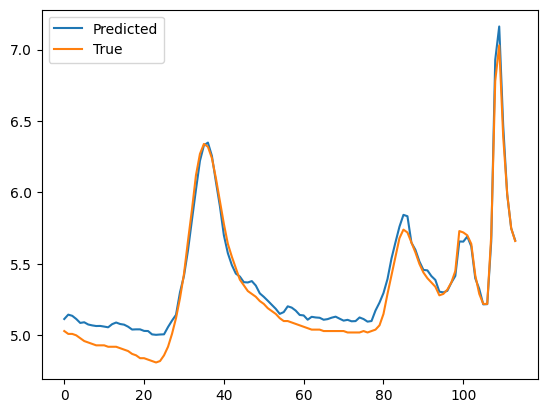

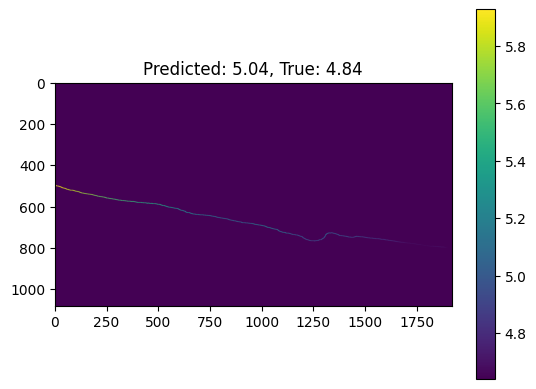

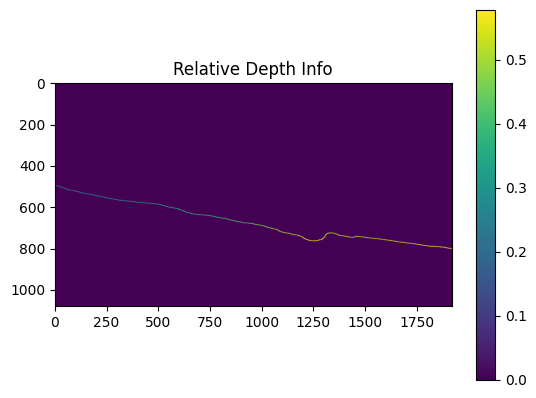

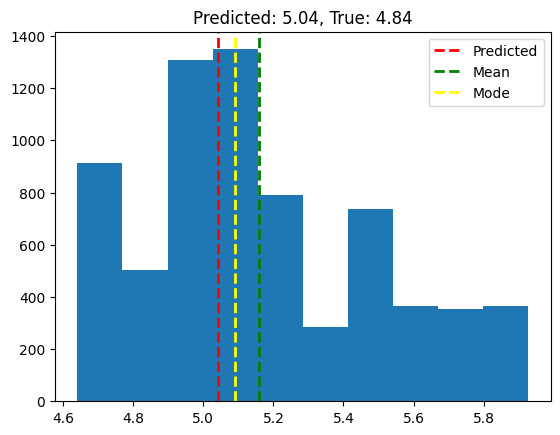

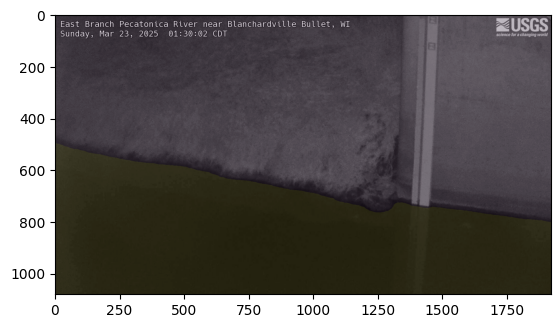

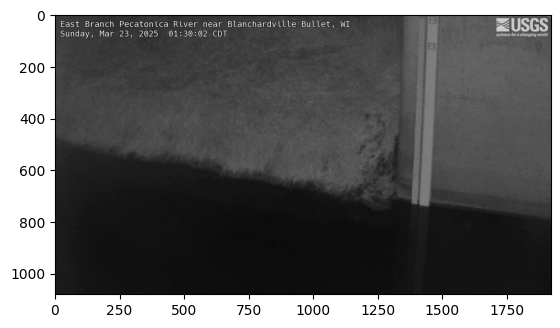

In [218]:
predicted_water_evevations = []
for idx, row in df.iterrows():
    mask_path = os.path.join(masks_dir, row['mask_filename'])
    if not os.path.exists(mask_path):
        print(f"Warning: Mask not found: {mask_path}")
        continue

    mask = load_mask(mask_path)
    pred = predict_elevation(elevation_map, rel_depth_map, mask, prediction_method="weighted_median")
    predicted_water_evevations.append(pred)

predicted_water_elevations = np.array(predicted_water_evevations)
true_water_elevations = df['00065']

plt.figure()
plt.plot(predicted_water_elevations)
plt.plot(true_water_elevations)
plt.legend(("Predicted", "True"))

# Calculate Error in Prediction
errors = np.abs(predicted_water_elevations-true_water_elevations)
mae = np.mean(errors)
print(f"MAE: {mae} ft")

# Show information on the worst prediciton 
worst_error_idx = np.argmax(errors)
mask2 = get_specific_est_info(worst_error_idx, elevation_map, rel_depth_map, df, images_dir, masks_dir)
